<a href="https://colab.research.google.com/github/basaaria123/Patient-Record-Validator/blob/main/Patient_Record_Validator_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== VALID RECORDS =====
ID      Name                Age   Phone       
--------------------------------------------------
401     Arun Kumar          30    9123456789  
402     Divya               22    9876543210  
403     Ravi                45    9988776655  
404     Sneha               28    9876501234  
405     Kiran               29    9234567890  
406     Meena               40    9345678901  
407     Ajay                35    9456789012  
408     Anu                 25    9567890123  
409     Vikas               31    9678901234  
410     Neha                28    9789012345  
411     Rahul               33    9890123456  
412     Priya               41    9901234567  
413     Sara                27    9012345678  
414     Manoj               50    9123456701  
415     Deepa               45    9234567012  
416     Harsha              21    9345670123  
417     Pooja               26    9456701234  
418     Rajesh              60    9567012345  
419     Amit                4

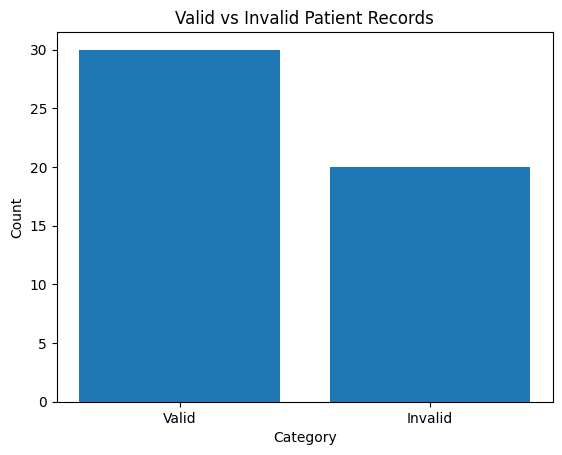

In [13]:
import matplotlib.pyplot as plt

# Custom Exceptions
class InvalidAgeError(Exception): pass
class MissingFieldError(Exception): pass
class FormatError(Exception): pass
class InvalidPhoneError(Exception): pass
class InvalidNameError(Exception): pass
class DuplicateIDError(Exception): pass


# Validate single record
def validate_patient(record, seen_ids):
    try:
        if record == "INVALID DATA":
            raise FormatError("Completely invalid record")

        fields = record.split(",")
        data = {}

        for field in fields:
            if ":" not in field:
                raise FormatError("Invalid field format")
            key, value = field.split(":")
            data[key.strip()] = value.strip()

        # Required fields
        required = ["ID", "Name", "Age", "Phone"]
        for field in required:
            if field not in data:
                raise MissingFieldError(f"Missing {field}")

        # Duplicate ID check
        if data["ID"] in seen_ids:
            raise DuplicateIDError("Duplicate ID found")
        seen_ids.add(data["ID"])

        # Name validation
        name = data["Name"]
        if name == "" or not name.replace(" ", "").isalpha():
            raise InvalidNameError("Invalid Name")

        # Age validation
        try:
            age = int(data["Age"])
            if age < 0 or age > 120:
                raise InvalidAgeError("Age must be between 0 and 120")
        except:
            raise InvalidAgeError("Age must be a number")

        # Phone validation
        phone = data["Phone"]
        if not (phone.isdigit() and len(phone) == 10):
            raise InvalidPhoneError("Phone must be 10 digits")

        return True, data

    except MissingFieldError as e:
        return False, ("Missing Field", str(e))
    except InvalidAgeError as e:
        return False, ("Invalid Age", str(e))
    except InvalidPhoneError as e:
        return False, ("Invalid Phone", str(e))
    except InvalidNameError as e:
        return False, ("Invalid Name", str(e))
    except DuplicateIDError as e:
        return False, ("Duplicate ID", str(e))
    except FormatError as e:
        return False, ("Format Error", str(e))


# Process all records
def get_valid_patients(patients):
    valid_records = []
    invalid_records = []
    seen_ids = set()

    for record in patients:
        is_valid, result = validate_patient(record, seen_ids)

        if is_valid:
            valid_records.append(result)
        else:
            error_type, message = result
            invalid_records.append({
                "record": record,
                "type": error_type,
                "error": message
            })

    return valid_records, invalid_records


# Graph
def plot_results(valid, invalid):
    labels = ["Valid", "Invalid"]
    values = [len(valid), len(invalid)]

    plt.figure()
    plt.bar(labels, values)
    plt.title("Valid vs Invalid Patient Records")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.show()


# ----------- MAIN DATA -----------

patients = [
    "ID:401,Name:Arun Kumar,Age:30,Phone:9123456789",
    "ID:431,Name:Test123,Age:30,Phone:9555555555",
    "ID:402,Name:Divya,Age:22,Phone:9876543210",
    "ID:432,Name:Meena,Age:abc,Phone:9876543210",
    "ID:403,Name:Ravi,Age:45,Phone:9988776655",
    "ID:433,Name:John,Phone:9876543210",
    "ID:404,Name:Sneha,Age:28,Phone:9876501234",
    "ID:434,Name:Sara,Age:30,Phone:12345",
    "ID:405,Name:Kiran,Age:29,Phone:9234567890",
    "ID:435,Name:Ali,Age:-5,Phone:9876543210",

    "ID:406,Name:Meena,Age:40,Phone:9345678901",
    "ID:436,Name:,Age:40,Phone:9876543210",
    "ID:407,Name:Ajay,Age:35,Phone:9456789012",
    "Name:NoID,Age:22,Phone:9876543210",
    "ID:408,Name:Anu,Age:25,Phone:9567890123",
    "ID:438,Age:30,Phone:9876543210",
    "ID:409,Name:Vikas,Age:31,Phone:9678901234",
    "ID:439,Name:Kavya,Phone:9876543210",
    "ID:410,Name:Neha,Age:28,Phone:9789012345",
    "INVALID DATA",

    "ID:411,Name:Rahul,Age:33,Phone:9890123456",
    "ID:440,Name:Raj,Age:200,Phone:9012309876",
    "ID:412,Name:Priya,Age:41,Phone:9901234567",
    "ID:441,Name:Simran,Age:twenty,Phone:9123409876",
    "ID:413,Name:Sara,Age:27,Phone:9012345678",
    "ID:442,Name:Amit,Age:45,Phone:abcd123456",
    "ID:414,Name:Manoj,Age:50,Phone:9123456701",
    "ID:443,Name:Bad123,Age:29,Phone:9678909876",
    "ID:415,Name:Deepa,Age:45,Phone:9234567012",
    "ID:444,Name:Deepa",

    "ID:416,Name:Harsha,Age:21,Phone:9345670123",
    "ID:445,Name:Manoj,Age:,Phone:9678909876",
    "ID:417,Name:Pooja,Age:26,Phone:9456701234",
    "ID:446,Name:Test,Age:30",
    "ID:418,Name:Rajesh,Age:60,Phone:9567012345",
    "ID:401,Name:Duplicate,Age:30,Phone:9999999999",
    "ID:419,Name:Amit,Age:45,Phone:9670123456",
    "RANDOM TEXT",
    "ID:420,Name:Geeta,Age:29,Phone:9781234567",
    "INVALID DATA",

    "ID:421,Name:Leela,Age:38,Phone:9892345678",
    "ID:422,Name:Sunil,Age:55,Phone:9903456789",
    "ID:423,Name:Anu,Age:20,Phone:9014567890",
    "ID:424,Name:Prakash,Age:60,Phone:9125678901",
    "ID:425,Name:Megha,Age:34,Phone:9236789012",
    "ID:426,Name:Ravi Kumar,Age:33,Phone:9347890123",
    "ID:427,Name:Kavya,Age:27,Phone:9458901234",
    "ID:428,Name:Harish,Age:36,Phone:9569012345",
    "ID:429,Name:Varun,Age:48,Phone:9670123499",
    "ID:430,Name:Good Name,Age:52,Phone:9781234999"
]


# Run
valid, invalid = get_valid_patients(patients)


# ----------- FORMATTED OUTPUT -----------

print("\n===== VALID RECORDS =====")
print(f"{'ID':<8}{'Name':<20}{'Age':<6}{'Phone':<12}")
print("-" * 50)

for v in valid:
    print(f"{v['ID']:<8}{v['Name']:<20}{v['Age']:<6}{v['Phone']:<12}")


print("\n===== INVALID RECORDS =====")
print(f"{'Record':<60}{'Error Type':<20}{'Message'}")
print("-" * 110)

for i in invalid:
    print(f"{i['record']:<60}{i['type']:<20}{i['error']}")


# ----------- GRAPH -----------

plot_results(valid, invalid)